# Vein Segmentation Training - v1 (pretrained ResNet34 backbone, updated dataset)

Goal: push test IoU up towards 0.85, using a faster-converging architecture than
the from-scratch Attention U-Net in the first notebook.

**What's different from the first notebook:**
- **Encoder is a pretrained ResNet34** (ImageNet weights) instead of a from-scratch CNN.
  Transfer learning converges in far fewer epochs, since the encoder already knows
  useful low/mid-level visual features - this is the main lever for reaching higher
  IoU within the same time budget.
- **Lighter attention**: dropped the 4x full attention-gates-on-every-skip (expensive,
  didn't clearly pay for itself last time). Kept a real multi-head self-attention block
  at the bottleneck (tiny at this resolution: 8x8 = 64 tokens with a 256px input) and a
  CBAM (channel+spatial attention) block right before the classification head.
- **Discriminative learning rates**: encoder fine-tunes slowly (it's already good),
  decoder trains fast (it's random-init and needs to learn from scratch).
- **Fixed the LR scheduler bug** from the first notebook (CosineAnnealingLR's `T_max`
  now matches the actual epoch cap, so it can't cycle back up and blow up training late
  in a run) + gradient clipping as a safety net.
- **Batch size 128** (up from 64) - ResNet34 at 256x256 is light for a 5090's 32GB.

**What is new in v1 (dataset):** trains on `segmentation_dataset_v1`, built by `build_dataset_v1.py`:
- Task_47 uses the latest manually refined annotations (2026-09-22 10:19:58 export); Task_44/45 use their latest exports.
- Adds the **longitudinal-view clip** (all 120 frames, masks derived from the green contour overlay), so the model sees long-axis veins.
  It is only ~0.7% of the data, so longitudinal *training* frames are oversampled (`LONG_OVERSAMPLE`).

Edit the model cell to swap in a different `torchvision` backbone (e.g. `resnet18` for
even more speed, `resnet50` for more capacity) if you want to explore further.


In [1]:
import json, time, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from IPython.display import clear_output, display

%matplotlib inline


## 1. Config

In [2]:
SEED = 42
DATA_DIR = Path("../segmentation_dataset_v1")

BATCH_SIZE = 64
MAX_EPOCHS = 30
PATIENCE = 6                  # stop if val IoU doesn't improve for 6 epochs
TRAIN_TIME_BUDGET_MIN = 25.0
LR_ENC, LR_DEC = 3e-4, 2e-3   # pretrained encoder slow, random decoder fast
WEIGHT_DECAY = 1e-4
LONG_OVERSAMPLE = 10          # repeat longitudinal train frames

OUT_DIR = Path("outputs_v1_fast")
OUT_DIR.mkdir(exist_ok=True)

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA GeForce RTX 5090


## 2. Load dataset tensors + train/val/test split

In [3]:
images = torch.load(DATA_DIR / "images.pt")   # uint8 [N,3,H,W]
masks  = torch.load(DATA_DIR / "masks.pt")    # uint8 [N,1,H,W]
with open(DATA_DIR / "meta.json") as f:
    meta = json.load(f)

print("images:", images.shape, images.dtype)
print("masks: ", masks.shape, masks.dtype)
print("total frames:", len(meta))
print("frames with a vein:", sum(m["has_vein"] for m in meta))
print("longitudinal frames:", sum(m.get("view") == "longitudinal" for m in meta))


images: torch.Size([16765, 3, 256, 256]) torch.uint8
masks:  torch.Size([16765, 1, 256, 256]) torch.uint8
total frames: 16765
frames with a vein: 13065
longitudinal frames: 120


In [4]:
n = len(meta)
idx = np.arange(n)
has_vein = np.array([m["has_vein"] for m in meta], dtype=np.int64)
is_long = np.array([m.get("view") == "longitudinal" for m in meta])

train_idx, temp_idx, y_train, y_temp = train_test_split(
    idx, has_vein, test_size=0.2, random_state=SEED, stratify=has_vein)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=SEED, stratify=y_temp)

long_train = train_idx[is_long[train_idx]]
train_idx = np.concatenate([train_idx] + [long_train] * (LONG_OVERSAMPLE - 1))
print(f"train/val/test sizes: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")
print(f"longitudinal: train(unique)={len(long_train)}, val={int(is_long[val_idx].sum())}, test={int(is_long[test_idx].sum())}")

# whole dataset lives on the GPU (~3.3 GB uint8) -> no DataLoader bottleneck in training
images_gpu = images.to(device)
masks_gpu = masks.to(device)
MEAN_G = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
STD_G = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

def get_batch(ids, augment):
    ids_t = torch.as_tensor(ids, device=device)
    x = images_gpu[ids_t].float() / 255.0
    y = masks_gpu[ids_t].float() / 255.0
    if augment:
        B = x.shape[0]
        r = lambda: torch.rand(B, 1, 1, 1, device=device)
        flip = r() < 0.5
        x = torch.where(flip, x.flip(3), x); y = torch.where(flip, y.flip(3), y)
        c, b = 0.8 + 0.4 * r(), 0.75 + 0.5 * r()                 # contrast, brightness
        m = x.mean((1, 2, 3), keepdim=True)
        x = (((x - m) * c + m) * b).clamp(0, 1) ** (0.8 + 0.4 * r())   # + gamma
        x = (x + 0.02 * torch.randn_like(x)).clamp(0, 1)          # speckle-like noise
        ang = (torch.rand(B, device=device) - 0.5) * 2 * math.radians(12)
        sc = 1 + (torch.rand(B, device=device) - 0.5) * 0.3
        tx, ty = [(torch.rand(B, device=device) - 0.5) * 0.2 for _ in range(2)]
        cs, sn = torch.cos(ang) / sc, torch.sin(ang) / sc
        theta = torch.stack([torch.stack([cs, -sn, tx], 1), torch.stack([sn, cs, ty], 1)], 1)
        grid = F.affine_grid(theta, x.shape, align_corners=False)
        x = F.grid_sample(x, grid, mode="bilinear", padding_mode="reflection", align_corners=False)
        y = F.grid_sample(y, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
    x = ((x - MEAN_G) / STD_G).contiguous(memory_format=torch.channels_last)
    return x, (y > 0.5).float()

train/val/test sizes: 14285 / 1676 / 1677
longitudinal: train(unique)=97, val=11, test=12


In [5]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class VeinSegDataset(Dataset):
    def __init__(self, images, masks, indices, augment=False):
        self.images, self.masks, self.indices, self.augment = images, masks, indices, augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        img = self.images[idx].float() / 255.0
        mask = self.masks[idx].float() / 255.0

        if self.augment:
            if torch.rand(1).item() < 0.5:
                img = torch.flip(img, dims=[2])
                mask = torch.flip(mask, dims=[2])
            if torch.rand(1).item() < 0.3:
                factor = 0.8 + 0.4 * torch.rand(1).item()
                img = torch.clamp(img * factor, 0, 1)

        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        mask = (mask > 0.5).float()
        return img, mask

train_ds = VeinSegDataset(images, masks, train_idx, augment=True)
val_ds   = VeinSegDataset(images, masks, val_idx, augment=False)
test_ds  = VeinSegDataset(images, masks, test_idx, augment=False)


## 3. Visualize a batch of examples

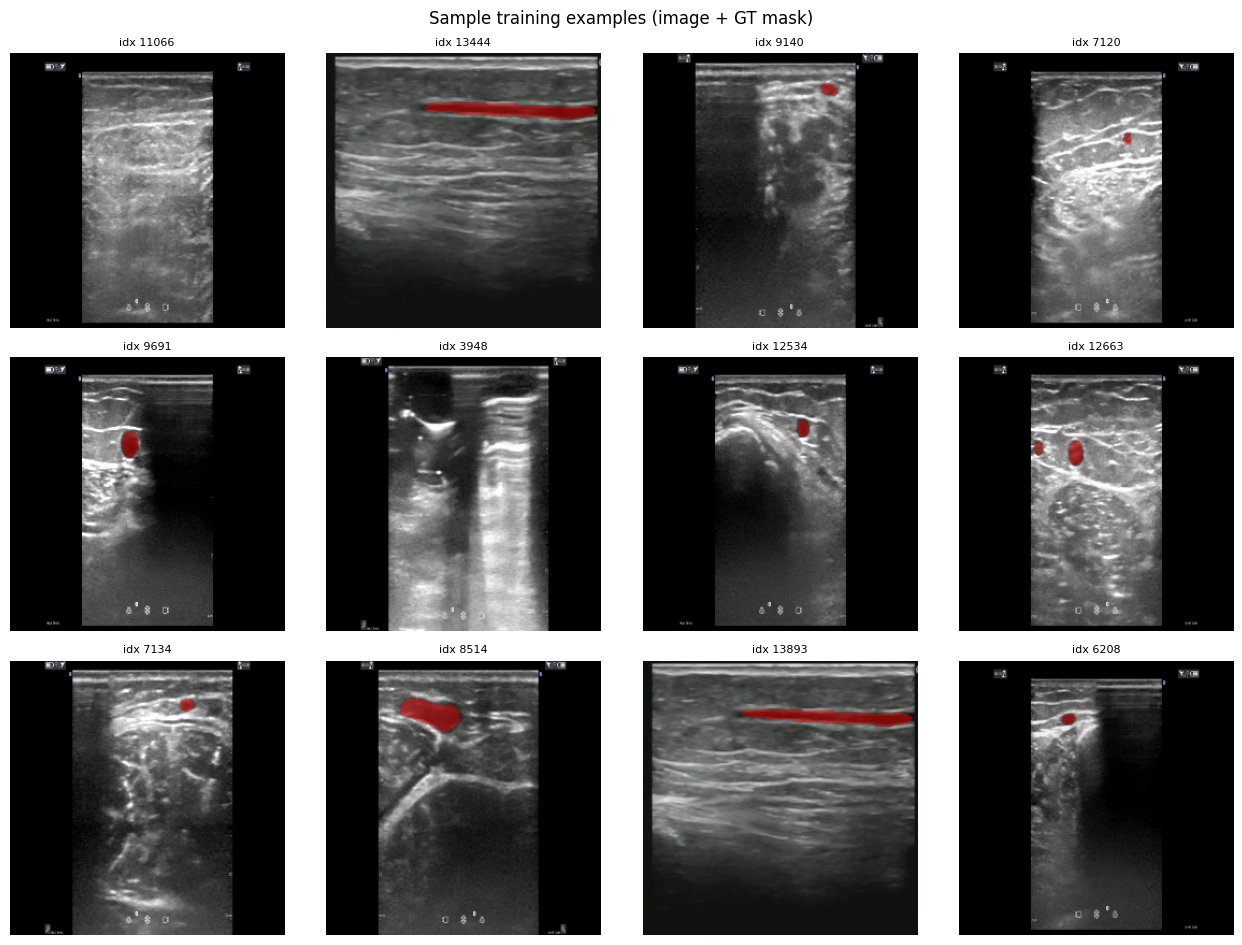

In [6]:
def denorm_img(img_tensor):
    img = img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

def show_examples(dataset, n=12, title=""):
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    cols = 4
    rows = int(np.ceil(len(idxs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.2))
    axes = np.array(axes).reshape(-1)
    for ax, i in zip(axes, idxs):
        img, mask = dataset[i]
        im = denorm_img(img)
        m = mask.squeeze(0).numpy()
        ax.imshow(im)
        ax.imshow(np.ma.masked_where(m == 0, m), cmap="autumn", alpha=0.45)
        ax.set_title(f"idx {i}", fontsize=8)
        ax.axis("off")
    for ax in axes[len(idxs):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

show_examples(train_ds, n=12, title="Sample training examples (image + GT mask)")


## 4. Model - pretrained ResNet34 U-Net
Plain (attention-free) U-Net decoder on an ImageNet-pretrained ResNet34, plus a full-resolution skip from the raw
input so boundaries stay sharp. Weights are tracked with an EMA, which is what gets validated and saved.

In [7]:
import copy

class Up(nn.Module):
    def __init__(self, cin, cskip, cout):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(cin + cskip, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(True),
            nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(True))
    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], 1))

class ResUNet(nn.Module):
    def __init__(self):
        super().__init__()
        r = tvm.resnet34(weights=tvm.ResNet34_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(r.conv1, r.bn1, r.relu)
        self.pool, self.l1, self.l2, self.l3, self.l4 = r.maxpool, r.layer1, r.layer2, r.layer3, r.layer4
        self.u4, self.u3, self.u2, self.u1 = Up(512, 256, 256), Up(256, 128, 128), Up(128, 64, 64), Up(64, 64, 32)
        self.u0 = nn.Sequential(nn.Conv2d(32 + 3, 16, 3, padding=1, bias=False), nn.BatchNorm2d(16), nn.ReLU(True))
        self.head = nn.Conv2d(16, 1, 1)
        self.enc_modules = [self.stem, self.l1, self.l2, self.l3, self.l4]
        self.dec_modules = [self.u4, self.u3, self.u2, self.u1, self.u0, self.head]
    def forward(self, x):
        s0 = self.stem(x); s1 = self.l1(self.pool(s0)); s2 = self.l2(s1); s3 = self.l3(s2); s4 = self.l4(s3)
        d = self.u4(s4, s3); d = self.u3(d, s2); d = self.u2(d, s1); d = self.u1(d, s0)
        d = F.interpolate(d, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return self.head(self.u0(torch.cat([d, x], 1)))   # full-res skip from the raw input keeps boundaries sharp

model = ResUNet().to(device).to(memory_format=torch.channels_last)
ema = copy.deepcopy(model).eval()
for p in ema.parameters():
    p.requires_grad_(False)

def ema_update(decay):
    with torch.no_grad():
        for pe, pm in zip(ema.state_dict().values(), model.state_dict().values()):
            if pe.dtype.is_floating_point:
                pe.mul_(decay).add_(pm.detach(), alpha=1 - decay)
            else:
                pe.copy_(pm)

n_params = sum(p.numel() for p in model.parameters())
print(f"model params: {n_params/1e6:.2f}M")
with torch.no_grad():
    print("output shape:", model(torch.randn(2, 3, 256, 256, device=device)).shape)

model params: 24.43M
output shape: torch.Size([2, 1, 256, 256])


## 5. Loss and metrics

In [8]:
def dice_loss(logits, target, eps=1e-6):
    probs = torch.sigmoid(logits).flatten(1)
    target = target.flatten(1)
    inter = (probs * target).sum(1)
    union = probs.sum(1) + target.sum(1)
    return 1 - ((2 * inter + eps) / (union + eps)).mean()

def focal_tversky(logits, target, a=0.6, b=0.4, g=0.75, eps=1.0):
    p = torch.sigmoid(logits).flatten(1); t = target.flatten(1)
    tp = (p * t).sum(1); fn = ((1 - p) * t).sum(1); fp = (p * (1 - t)).sum(1)
    return ((1 - (tp + eps) / (tp + a * fn + b * fp + eps)) ** g).mean()   # a>b penalises missed vein pixels more

bce_loss = nn.BCEWithLogitsLoss()

def combined_loss(logits, target):
    return bce_loss(logits, target) + dice_loss(logits, target) + focal_tversky(logits, target)

@torch.no_grad()
def compute_metrics(logits, target, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float().flatten(1)
    target_f = target.flatten(1)
    inter = (preds * target_f).sum(1)
    union = preds.sum(1) + target_f.sum(1) - inter
    iou = (inter + eps) / (union + eps)
    dice = (2 * inter + eps) / (preds.sum(1) + target_f.sum(1) + eps)
    acc = (preds == target_f).float().mean(1)
    return iou.mean().item(), dice.mean().item(), acc.mean().item()

## 6. Train
Whole dataset lives on the GPU, augmentation (flip, brightness/contrast/gamma, noise, small rotate/scale/shift) runs on the GPU,
bf16 autocast, one-cycle LR (warmup then decay, no cycling back up), gradient clipping and NaN-gradient skipping so training
can't collapse, early stopping on val IoU. Loss = BCE + Dice + Focal-Tversky (penalises under-segmentation / shrinking).

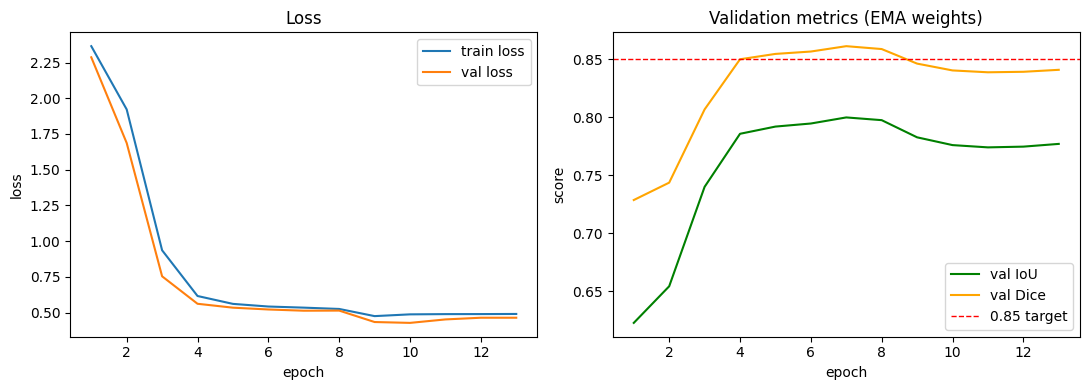

epoch  13 |   3.3 min | train_loss 0.4900 | val_loss 0.4636 | val_iou 0.7772 | best 0.8000
  skipped 222 non-finite gradient steps this epoch
early stopping
training finished. best val IoU: 0.8000


<All keys matched successfully>

In [9]:
enc_params = [p for m in model.enc_modules for p in m.parameters()]
dec_params = [p for m in model.dec_modules for p in m.parameters()]
optimizer = torch.optim.AdamW([{"params": enc_params, "lr": LR_ENC},
                               {"params": dec_params, "lr": LR_DEC}], weight_decay=WEIGHT_DECAY)
steps_per_epoch = len(train_idx) // BATCH_SIZE
# schedule length = real number of steps, so LR only goes warmup -> down (never cycles back up)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=[LR_ENC, LR_DEC], total_steps=MAX_EPOCHS * steps_per_epoch,
    pct_start=0.1, anneal_strategy="cos", div_factor=20, final_div_factor=200)

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}
best_val_iou, best_state, bad_epochs, step = -1.0, None, 0, 0
time_budget_s = TRAIN_TIME_BUDGET_MIN * 60
t_start = time.time()
epoch = 0

def live_plot():
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    ax1.plot(history["epoch"], history["train_loss"], label="train loss")
    ax1.plot(history["epoch"], history["val_loss"], label="val loss")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.set_title("Loss")
    ax2.plot(history["epoch"], history["val_iou"], label="val IoU", color="green")
    ax2.plot(history["epoch"], history["val_dice"], label="val Dice", color="orange")
    ax2.axhline(0.85, color="red", linestyle="--", linewidth=1, label="0.85 target")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("score"); ax2.legend(); ax2.set_title("Validation metrics (EMA weights)")
    fig.tight_layout(); plt.show()
    e = history["epoch"][-1]
    print(f"epoch {e:3d} | {(time.time()-t_start)/60:5.1f} min | train_loss {history['train_loss'][-1]:.4f} | "
          f"val_loss {history['val_loss'][-1]:.4f} | val_iou {history['val_iou'][-1]:.4f} | best {best_val_iou:.4f}")

while epoch < MAX_EPOCHS and (time.time() - t_start) < time_budget_s:
    epoch += 1
    model.train()
    perm = np.random.permutation(train_idx)
    running, nb, skipped = 0.0, 0, 0
    for b in range(steps_per_epoch):
        x, y = get_batch(perm[b * BATCH_SIZE:(b + 1) * BATCH_SIZE], augment=True)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            logits = model(x)
        loss = combined_loss(logits.float(), y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if torch.isfinite(gnorm):
            optimizer.step()
        else:
            skipped += 1                              # NaN/inf gradient -> skip step instead of corrupting weights
        scheduler.step(); step += 1
        ema_update(min(0.998, (1 + step) / (10 + step)))
        running += loss.item(); nb += 1
    train_loss = running / max(nb, 1)

    ema.eval()
    vl = vi = vd = 0.0; vb = 0
    with torch.no_grad():
        for i in range(0, len(val_idx), 128):
            x, y = get_batch(val_idx[i:i + 128], augment=False)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                logits = ema(x).float()
            iou, dice, _ = compute_metrics(logits, y)
            vl += combined_loss(logits, y).item(); vi += iou; vd += dice; vb += 1
    val_loss, val_iou, val_dice = vl / vb, vi / vb, vd / vb

    for k, v in zip(history, [epoch, train_loss, val_loss, val_iou, val_dice]):
        history[k].append(v)

    if val_iou > best_val_iou:
        best_val_iou, bad_epochs = val_iou, 0
        best_state = {k: v.detach().cpu().clone() for k, v in ema.state_dict().items()}
        torch.save(best_state, OUT_DIR / "best_model.pt")
    else:
        bad_epochs += 1
    live_plot()
    if skipped:
        print(f"  skipped {skipped} non-finite gradient steps this epoch")
    if bad_epochs >= PATIENCE:
        print("early stopping"); break

print(f"training finished. best val IoU: {best_val_iou:.4f}")
model.load_state_dict(best_state)   # the test / visualisation cells below evaluate the best EMA weights

## 7. Evaluate on the held-out test set

In [10]:
assert best_state is not None, "run the training cell (section 6) before evaluating"
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

model.eval()
test_iou_sum = test_dice_sum = test_acc_sum = 0.0
test_batches = 0
with torch.no_grad():
    for imgs, msks in test_loader:
        imgs, msks = imgs.to(device, non_blocking=True), msks.to(device, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
        iou, dice, acc = compute_metrics(logits, msks)
        test_iou_sum += iou; test_dice_sum += dice; test_acc_sum += acc
        test_batches += 1

test_iou = test_iou_sum / max(test_batches, 1)
test_dice = test_dice_sum / max(test_batches, 1)
test_acc = test_acc_sum / max(test_batches, 1)
print(f"TEST  IoU: {test_iou:.4f}   Dice: {test_dice:.4f}   PixelAcc: {test_acc:.4f}")
if test_iou >= 0.85:
    print("target reached (>= 0.85 IoU)")
else:
    print(f"below 0.85 target by {0.85 - test_iou:.4f} - consider more epochs, a bigger backbone (resnet50), or higher input resolution")

summary = {
    "n_train": len(train_idx), "n_val": len(val_idx), "n_test": len(test_idx),
    "epochs_trained": epoch, "best_val_iou": best_val_iou,
    "test_iou": test_iou, "test_dice": test_dice, "test_pixel_acc": test_acc,
    "model_params_millions": n_params / 1e6,
}
with open(OUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
summary

TEST  IoU: 0.8138   Dice: 0.8736   PixelAcc: 0.9990
below 0.85 target by 0.0362 - consider more epochs, a bigger backbone (resnet50), or higher input resolution


{'n_train': 14285,
 'n_val': 1676,
 'n_test': 1677,
 'epochs_trained': 13,
 'best_val_iou': 0.7999762381826129,
 'test_iou': 0.8137790538646557,
 'test_dice': 0.8736153068365874,
 'test_pixel_acc': 0.9989841558315136,
 'model_params_millions': 24.434337}

## 8. Visualize test predictions

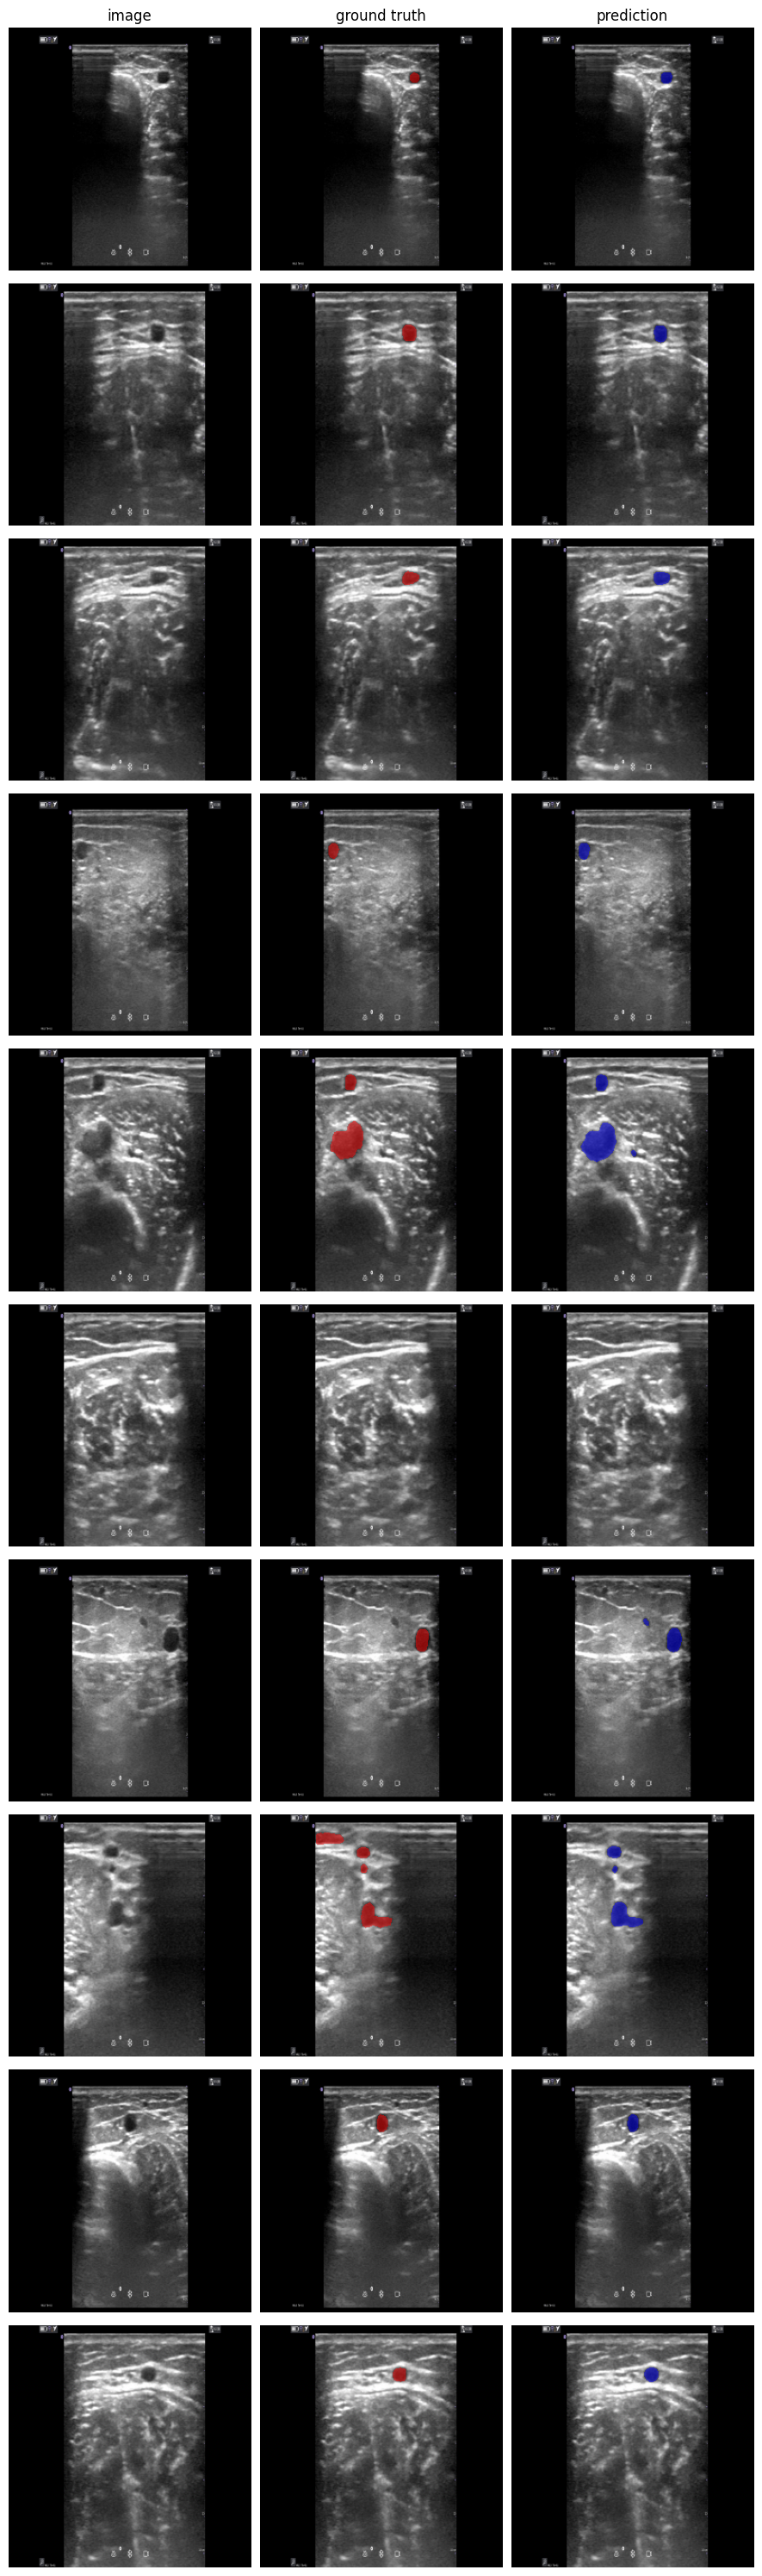

In [11]:
def show_predictions(model, dataset, n=12):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    fig, axes = plt.subplots(len(idxs), 3, figsize=(9, 3 * len(idxs)))
    with torch.no_grad():
        for r, i in enumerate(idxs):
            img, mask = dataset[i]
            logits = model(img.unsqueeze(0).to(device))
            pred = (torch.sigmoid(logits) > 0.5).float().cpu().squeeze().numpy()
            im = denorm_img(img)
            gt = mask.squeeze(0).numpy()

            axes[r, 0].imshow(im); axes[r, 0].axis("off")
            axes[r, 1].imshow(im); axes[r, 1].imshow(np.ma.masked_where(gt == 0, gt), cmap="autumn", alpha=0.5); axes[r, 1].axis("off")
            axes[r, 2].imshow(im); axes[r, 2].imshow(np.ma.masked_where(pred == 0, pred), cmap="winter", alpha=0.5); axes[r, 2].axis("off")
            if r == 0:
                axes[r, 0].set_title("image"); axes[r, 1].set_title("ground truth"); axes[r, 2].set_title("prediction")
    fig.tight_layout()
    plt.show()

show_predictions(model, test_ds, n=10)

## 9. Save the trained model

In [ ]:
torch.save(model.state_dict(), OUT_DIR / "final_model.pt")
print("saved to", (OUT_DIR / "final_model.pt").resolve())

saved to C:\Users\Krish\Downloads\Cygnus_Med_Demo\Vein_Annotations\DL_Training\outputs_v1_fast\final_model.pt
